In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import config

# Verify data is accessible
try:
    config.assert_data_exists()
    print("✓ Data path:", config.DATA_ROOT)
except FileNotFoundError as e:
    print("✗ Data path error:", e)

# Data loading utility — use this instead of pd.read_csv() directly
# It handles column name cleaning (the CSV has spaces in headers)
def load_csv(path):
    """Load a CSV from config.DATA_RAW or config.DATA_PROCESSED with cleaned column names."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    # Also strip whitespace from all string/object column VALUES
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].str.strip()
    return df

# Example usage:
# df = load_csv(config.DATA_RAW / "Airlines.csv")
# df = load_csv(config.DATA_PROCESSED / "Airlines_enriched.csv")

✓ Data path: /Users/hareee234/Library/CloudStorage/GoogleDrive-hareee234@gmail.com/My Drive/sem-8/CMPE188/flight-delay-proj-data


# 03 — Feature Engineering + Baseline Model Comparison
**CMPE 188 | Flight Delay Prediction**

Goals:
- Engineer derived features from existing columns only (no external data)
- Establish a benchmark using raw + derived features
- Compare Random Forest vs XGBoost on equal footing
- Evaluate with accuracy, ROC-AUC, and classification report

*Weather enrichment (OpenMeteo API) is handled separately in `02_feature_engineering.ipynb`.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.feature_selection import SelectKBest, chi2
from xgboost import XGBClassifier

DATA_PATH = str(config.DATA_PROCESSED / 'Airlines_enriched.csv')
df = load_csv(DATA_PATH)

# Drop columns with no predictive signal
df = df.drop(columns=["id", "Flight"])

print(df.shape)
df.head()

(539383, 19)


,Airline,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay,from_lat,from_lon,from_elevation_ft,from_avg_temperature,from_avg_precipitation,from_avg_wind_speed,to_lat,to_lon,to_elevation_ft,to_avg_temperature,to_avg_precipitation,to_avg_wind_speed
0,CO,SFO,IAH,3,15,205,1,37.619806,-122.374821,13.0,14.806027,1.611836,8.456712,29.984400,-95.341400,97.0,20.315616,2.408658,11.432877
1,US,PHX,CLT,3,15,222,1,33.435302,-112.005905,1135.0,22.637808,0.967808,8.398904,35.214001,-80.943100,748.0,16.326301,2.777151,9.520274
2,AA,LAX,DFW,3,20,165,1,33.942501,-118.407997,125.0,17.383836,0.947096,8.374247,32.896801,-97.038002,607.0,18.216712,2.134110,14.586849
3,AA,SFO,DFW,3,20,195,1,37.619806,-122.374821,13.0,14.806027,1.611836,8.456712,32.896801,-97.038002,607.0,18.216712,2.134110,14.586849
4,AS,ANC,SEA,3,30,202,0,61.179004,-149.992561,152.0,2.723562,2.639945,6.909315,47.447943,-122.310276,433.0,10.675616,4.002575,8.618356


## 1. Derived Feature Engineering

Features computed from existing columns only — no external data required.

| Feature | Source | Description |
|---|---|---|
| `time_bucket` | `Time` | morning / afternoon / evening / night |
| `is_peak_hour` | `Time` | 1 if 7–9 am or 5–8 pm |
| `route_volume` | `AirportFrom` + `AirportTo` | flight count per origin→dest pair (congestion proxy) |
| `airline_delay_rate` | `Airline` + `Delay` | historical delay rate per carrier — **computed on train split only** to avoid leakage |
| `route_delay_rate` | `AirportFrom` + `AirportTo` + `Delay` | historical delay rate per route — **computed on train split only** to avoid leakage |
| `flight_seq_delay_rate` | `Airline` + `Flight` + `DayOfWeek` + `Delay` | delay rate per flight number on a given day — proxy for propagation delay (no tail number available) — **computed on train split only** |

In [3]:
def add_time_features(df):
    """Add time_bucket and is_peak_hour from the Time column (minutes from midnight)."""
    df = df.copy()
    hours = df["Time"] / 60
    df["time_bucket"] = pd.cut(
        hours,
        bins=[0, 6, 12, 18, 24],
        labels=["night", "morning", "afternoon", "evening"],
        right=False,
    ).astype(str)
    df["is_peak_hour"] = ((hours >= 7) & (hours < 9) | (hours >= 17) & (hours < 20)).astype(int)
    return df

def add_route_volume(df):
    """Count flights per origin→destination pair as a congestion proxy."""
    df = df.copy()
    route_counts = df.groupby(["AirportFrom", "AirportTo"]).transform("count")["Time"]
    df["route_volume"] = route_counts
    return df

df = add_time_features(df)
df = add_route_volume(df)
print("Added time_bucket, is_peak_hour, route_volume")
print(df[["Time", "time_bucket", "is_peak_hour", "route_volume"]].head(10))

Added time_bucket, is_peak_hour, route_volume
   Time time_bucket  is_peak_hour  route_volume
0    15       night             0           231
1    15       night             0           253
2    20       night             0           544
3    20       night             0           329
4    30       night             0           447
5    30       night             0           328
6    30       night             0           190
7    30       night             0           259
8    35       night             0           177
9    40       night             0           304


## 2. Train/Test Split + Airline Delay Rate

`airline_delay_rate` is computed on the **training split only** and then mapped to the test set — this prevents target leakage.

In [4]:
target = "Delay"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute airline delay rate on train only, then apply to both splits
airline_delay_rate = X_train.join(y_train).groupby("Airline")[target].mean()
global_rate = y_train.mean()  # fallback for unseen airlines

X_train = X_train.copy()
X_test = X_test.copy()
X_train["airline_delay_rate"] = X_train["Airline"].map(airline_delay_rate).fillna(global_rate)
X_test["airline_delay_rate"] = X_test["Airline"].map(airline_delay_rate).fillna(global_rate)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nairline_delay_rate sample:")
print(airline_delay_rate.sort_values(ascending=False))

Train: (431506, 22), Test: (107877, 22)

airline_delay_rate sample:
Airline
WN    0.697105
CO    0.567622
B6    0.465076
F9    0.455148
OO    0.453425
DL    0.449932
EV    0.400475
9E    0.397605
AA    0.388565
XE    0.380153
MQ    0.346699
AS    0.341466
US    0.334873
UA    0.326272
HA    0.318691
FL    0.301984
OH    0.276613
YV    0.242277
Name: Delay, dtype: float64


In [5]:
# ── Route delay rate ──────────────────────────────────────────────────────────
# Historical delay rate per origin→destination pair.
# Same anti-leakage pattern as airline_delay_rate: computed on train split only.
route_delay_rate_map = (
    X_train.join(y_train)
    .groupby(["AirportFrom", "AirportTo"])[target]
    .mean()
)
X_train["route_delay_rate"] = (
    X_train.set_index(["AirportFrom", "AirportTo"])
    .index.map(route_delay_rate_map)
    .values
)
X_train["route_delay_rate"] = X_train["route_delay_rate"].fillna(global_rate)
X_test["route_delay_rate"] = (
    X_test.set_index(["AirportFrom", "AirportTo"])
    .index.map(route_delay_rate_map)
    .values
)
X_test["route_delay_rate"] = X_test["route_delay_rate"].fillna(global_rate)

print("route_delay_rate stats (train):")
print(X_train["route_delay_rate"].describe().round(4))
print("\nHighest-delay routes (top 10):")
print(route_delay_rate_map.sort_values(ascending=False).head(10))

# ── Flight sequence delay rate (propagation proxy) ────────────────────────────
# The dataset has no tail number, so we cannot track individual aircraft rotations.
# This proxy encodes how often a given flight number (per airline + day of week)
# is delayed — a noisy stand-in for propagation delay.
# Flight column was dropped from df; re-attach from raw CSV by index.
_flight_col = load_csv(DATA_PATH)["Flight"]
X_train["_flight"] = _flight_col.loc[X_train.index].values
X_test["_flight"]  = _flight_col.loc[X_test.index].values

flight_seq_rate_map = (
    X_train.join(y_train)
    .groupby(["Airline", "_flight", "DayOfWeek"])[target]
    .mean()
)
X_train["flight_seq_delay_rate"] = (
    X_train.set_index(["Airline", "_flight", "DayOfWeek"])
    .index.map(flight_seq_rate_map)
    .values
)
X_train["flight_seq_delay_rate"] = X_train["flight_seq_delay_rate"].fillna(global_rate)
X_test["flight_seq_delay_rate"] = (
    X_test.set_index(["Airline", "_flight", "DayOfWeek"])
    .index.map(flight_seq_rate_map)
    .values
)
X_test["flight_seq_delay_rate"] = X_test["flight_seq_delay_rate"].fillna(global_rate)

# Drop the temporary _flight column — it was only needed for the groupby
X_train = X_train.drop(columns=["_flight"])
X_test  = X_test.drop(columns=["_flight"])

print("\nflight_seq_delay_rate stats (train):")
print(X_train["flight_seq_delay_rate"].describe().round(4))

# Sanity check: if this collapses to near airline_delay_rate it adds little signal
corr = X_train[["airline_delay_rate", "flight_seq_delay_rate", "route_delay_rate"]].corr()
print("\nCorrelation between rate features:")
print(corr.round(3))

route_delay_rate stats (train):
count    431506.0000
mean          0.4454
std           0.1519
min           0.0000
25%           0.3400
50%           0.4314
75%           0.5278
max           1.0000
Name: route_delay_rate, dtype: float64

Highest-delay routes (top 10):
AirportFrom  AirportTo
DSM          MCO          1.0
BGR          LGA          1.0
AVP          JFK          1.0
STL          SAN          1.0
IAH          EGE          1.0
MSP          SJU          1.0
LAX          MTJ          1.0
MTJ          LAX          1.0
ORD          GEG          1.0
MSP          PVD          1.0
Name: Delay, dtype: float64



flight_seq_delay_rate stats (train):
count    431506.0000
mean          0.4454
std           0.3037
min           0.0000
25%           0.2500
50%           0.4444
75%           0.6667
max           1.0000
Name: flight_seq_delay_rate, dtype: float64

Correlation between rate features:
                       airline_delay_rate  flight_seq_delay_rate  \
airline_delay_rate                  1.000                  0.435   
flight_seq_delay_rate               0.435                  1.000   
route_delay_rate                    0.605                  0.442   

                       route_delay_rate  
airline_delay_rate                0.605  
flight_seq_delay_rate             0.442  
route_delay_rate                  1.000  


## 3. Preprocessing Pipeline

Shared across both models: OHE for categoricals, MinMaxScaler for numerics, SelectKBest chi2 for feature selection.

In [6]:
categorical_cols = ["Airline", "AirportFrom", "AirportTo", "time_bucket"]
numeric_cols = [
    "DayOfWeek", "Time", "Length",
    "is_peak_hour", "route_volume",
    "airline_delay_rate", "route_delay_rate", "flight_seq_delay_rate",
    # Enriched geographic + weather features
    "from_lat", "from_lon", "from_elevation_ft",
    "from_avg_temperature", "from_avg_precipitation", "from_avg_wind_speed",
    "to_lat", "to_lon", "to_elevation_ft",
    "to_avg_temperature", "to_avg_precipitation", "to_avg_wind_speed",
]

# Keep only columns that exist in the dataset
categorical_cols = [col for col in categorical_cols if col in X.columns]
numeric_cols = [col for col in numeric_cols if col in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", MinMaxScaler(), numeric_cols),
    ]
)

# k=50 is a reasonable upper bound given the OHE expansion; tuned in notebook 04
selector = SelectKBest(score_func=chi2, k=50)

print("Categorical:", categorical_cols)
print("Numeric:    ", numeric_cols)

Categorical: ['Airline', 'AirportFrom', 'AirportTo', 'time_bucket']
Numeric:     ['DayOfWeek', 'Time', 'Length', 'is_peak_hour', 'route_volume', 'from_lat', 'from_lon', 'from_elevation_ft', 'from_avg_temperature', 'from_avg_precipitation', 'from_avg_wind_speed', 'to_lat', 'to_lon', 'to_elevation_ft', 'to_avg_temperature', 'to_avg_precipitation', 'to_avg_wind_speed']


## 4. XGBoost Baseline

In [7]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", selector),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
    )),
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost  |  Accuracy: {xgb_acc:.4f}  |  ROC-AUC: {xgb_auc:.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=["No Delay", "Delayed"]))

XGBoost  |  Accuracy: 0.6409  |  ROC-AUC: 0.6887

              precision    recall  f1-score   support

    No Delay       0.63      0.88      0.73     59824
     Delayed       0.70      0.34      0.46     48053

    accuracy                           0.64    107877
   macro avg       0.66      0.61      0.60    107877
weighted avg       0.66      0.64      0.61    107877



## 5. Random Forest Baseline

In [8]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", selector),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest  |  Accuracy: {rf_acc:.4f}  |  ROC-AUC: {rf_auc:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=["No Delay", "Delayed"]))

Random Forest  |  Accuracy: 0.6364  |  ROC-AUC: 0.6825

              precision    recall  f1-score   support

    No Delay       0.62      0.91      0.74     59824
     Delayed       0.73      0.29      0.42     48053

    accuracy                           0.64    107877
   macro avg       0.67      0.60      0.58    107877
weighted avg       0.67      0.64      0.59    107877



## 6. Side-by-Side Results

                 Feature Set  Accuracy   ROC-AUC
Model                                           
XGBoost        raw + derived  0.640878  0.688734
Random Forest  raw + derived  0.636391  0.682526


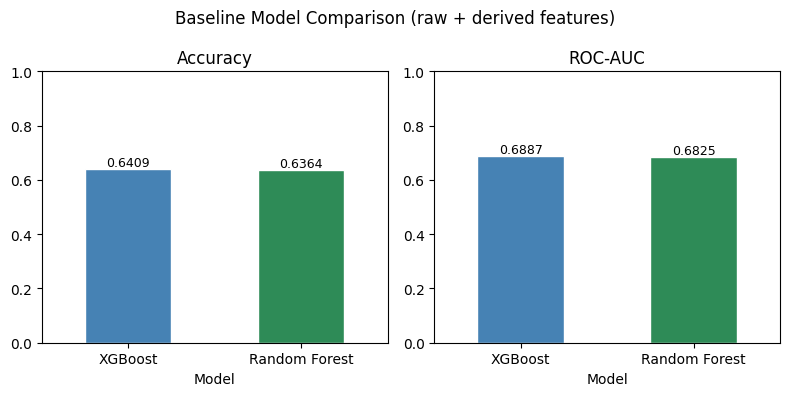

In [9]:
results = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest"],
    "Feature Set": ["raw + derived", "raw + derived"],
    "Accuracy": [xgb_acc, rf_acc],
    "ROC-AUC": [xgb_auc, rf_auc],
})
results = results.set_index("Model")
print(results.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, metric in zip(axes, ["Accuracy", "ROC-AUC"]):
    results[metric].plot(kind="bar", ax=ax, color=["steelblue", "seagreen"], edgecolor="white")
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Baseline Model Comparison (raw + derived features)")
plt.tight_layout()
plt.show()